<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

## **Consigna del Desafío 3**

- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.

## **Resolución del Desafío 3**

### Corpus elegido: "Las Aventuras de Sherlock Holmes" (Arthur Conan Doyle)

Voy a usar el texto de *Las Aventuras de Sherlock Holmes* (la colección de doce cuentos de 1892) de Arthur Conan Doyle, en español, scrapeada de [textos.info](https://www.textos.info/arthur-conan-doyle/las-aventuras-de-sherlock-holmes/ebook) con el mismo método que el notebook de ejemplo de la cátedra (BeautifulSoup sobre el HTML).

**Nota:** originalmente había elegido *Estudio en Escarlata* (la primera novela de Sherlock Holmes), pero al scrapearla noté que textos.info solo permite leer un fragmento de esa obra por temas de copyright (el HTML trae el aviso *"Este texto podría estar protegido por copyright: se permite la lectura de un fragmento"* y el texto resultante queda en apenas ~2.500 caracteres, inútil para entrenar). Comprobé que *Las Aventuras de Sherlock Holmes* sí está disponible completa y sin esa restricción (615k caracteres), así que uso esa colección en su lugar, manteniendo el mismo autor y universo.

Elegí un libro en vez de las letras de canciones del `songs_dataset` (que usé en el desafío 2) porque para un modelo de lenguaje por caracteres conviene un corpus grande y con prosa "continua" (oraciones largas, gramaticalmente completas), a diferencia de las letras de canciones que son mayormente versos cortos y repetitivos. Un libro completo da bastantes más caracteres de entrenamiento y una estructura sintáctica más rica para que la red aprenda.

Primero importo las librerías que voy a necesitar a lo largo de todo el notebook.

In [1]:
import os
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bs4 as bs

import tensorflow as tf
from tensorflow import keras
from keras.utils import pad_sequences
from keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Embedding
from keras.models import Sequential
from scipy.special import softmax

# Fijo una semilla para que la separación train/val y el entrenamiento sean reproducibles
SEED = 19
np.random.seed(SEED)
tf.random.set_seed(SEED)

### 1 - Datos

Descargo el HTML del libro y lo parseo igual que en el ejemplo de la cátedra: junto el texto de todos los párrafos (`<p>`) en un único string y lo paso a minúsculas (para reducir el tamaño del vocabulario de caracteres, ya que a nivel char-level `A` y `a` serían tokens distintos si no normalizara). Guardo el resultado en un archivo local para no tener que volver a pegarle a textos.info cada vez que reinicio el notebook.

In [2]:
CORPUS_PATH = 'las_aventuras_de_sherlock_holmes.txt'
URL = 'https://www.textos.info/arthur-conan-doyle/las-aventuras-de-sherlock-holmes/ebook'

if os.access(CORPUS_PATH, os.F_OK) is False:
    raw_html = urllib.request.urlopen(URL).read()

    # Parsear artículo, 'lxml' es el parser a utilizar
    article_html = bs.BeautifulSoup(raw_html, 'lxml')

    # Encontrar todos los párrafos del HTML (bajo el tag <p>) y unirlos en un solo string
    article_paragraphs = article_html.find_all('p')
    article_text = ''
    for para in article_paragraphs:
        article_text += para.text + ' '

    with open(CORPUS_PATH, 'w', encoding='utf-8') as f:
        f.write(article_text)
    print("Descargado desde textos.info y guardado en cache local.")
else:
    with open(CORPUS_PATH, 'r', encoding='utf-8') as f:
        article_text = f.read()
    print("El corpus ya se encuentra descargado, lo leo desde cache local.")

# pasar todo el texto a minúscula
article_text = article_text.lower()

print("Cantidad de caracteres en el corpus:", len(article_text))

Descargado desde textos.info y guardado en cache local.
Cantidad de caracteres en el corpus: 608251


In [3]:
# en article_text se encuentra el texto completo del libro
article_text[:1000]

' a\n    mi viejo maestro,\n    joseph bell, m.d., &c.\n    de\n    2, melville crescent,\n    edimburgo ella es siempre, para \nsherlock holmes, la mujer rara vez le he oído hablar de ella aplicándole\n otro nombre. a los ojos de sherlock holmes, eclipsa y sobrepasa a todo \nsu sexo. no es que haya sentido por irene adler nada que se parezca al \namor. su inteligencia fría, llena de precisión, pero admirablemente \nequilibrada, era en extremo opuesta a cualquier clase de emociones. yo \nle considero como la máquina de razonar y de observar más perfecta que \nha conocido el mundo; pero como enamorado, no habría sabido estar en su \npapel. si alguna vez hablaba de los sentimientos más tiernos, lo hacía \ncon mofa y sarcasmo. admirables como tema para el observador, excelentes\n para descorrer el velo de los móviles y de los actos de las personas. \npero el hombre entrenado en el razonar que admitiese intrusiones \nsemejantes en su temperamento delicado y finamente ajustado, daría con \n

### 2 - Limpieza de espacios

Antes de armar el vocabulario, inspeccioné qué caracteres únicos hay en `article_text` (ver siguiente sección) y noté que, además de letras, números y puntuación normal del español (incluyendo tildes, `ñ`, `¿¡`, comillas tipográficas y raya de diálogo `—`, todos esperables en un libro), había varios caracteres de espaciado distintos: tabs (`\t`), saltos de línea (`\n`), y hasta espacios "duros" (`\xa0`, *non-breaking space*) que vienen del HTML original. Esto pasa porque `textos.info` indenta y formatea el texto con espacios en blanco variados dentro de cada `<p>`.

Si no lo limpio, el vocabulario de caracteres queda inflado con variantes de "espacio en blanco" que en la práctica significan lo mismo (un separador de palabras), lo cual solo le agrega ruido al modelo sin aportar información real. Por eso colapso cualquier secuencia de espacios en blanco (de cualquier tipo) a un único espacio simple.

In [4]:
import re

# colapso cualquier corrida de espacios en blanco (espacio, tab, \n, \r, nbsp...) a un único espacio
article_text = re.sub(r'\s+', ' ', article_text).strip()

print("Cantidad de caracteres luego de limpiar espacios:", len(article_text))
article_text[:300]

Cantidad de caracteres luego de limpiar espacios: 601309


'a mi viejo maestro, joseph bell, m.d., &c. de 2, melville crescent, edimburgo ella es siempre, para sherlock holmes, la mujer rara vez le he oído hablar de ella aplicándole otro nombre. a los ojos de sherlock holmes, eclipsa y sobrepasa a todo su sexo. no es que haya sentido por irene adler nada que'

### 3 - Vocabulario de caracteres

A diferencia de un modelo de lenguaje tokenizado por palabras (donde el vocabulario puede ser de miles o decenas de miles de términos y hay que preocuparse por palabras fuera de vocabulario), acá el vocabulario es simplemente el conjunto de caracteres únicos que aparecen en el corpus. Con un alfabeto como el español más puntuación, esperamos que sea un vocabulario chico (unas pocas decenas de símbolos), lo cual simplifica mucho el problema de clasificación en cada paso de tiempo (la capa de salida solo tiene que elegir entre esa cantidad de clases).

Construyo `char2idx` (el tokenizador: de carácter a índice) y `idx2char` (el detokenizador: de índice a carácter, para poder reconstruir texto a partir de las predicciones del modelo).

In [5]:
# el vocabulario es el conjunto único de caracteres que existe en todo el texto
# lo ordeno para que el mapeo carácter->índice sea determinístico (reproducible)
chars_vocab = sorted(set(article_text))
vocab_size = len(chars_vocab)

print("Cantidad de caracteres distintos (vocab_size):", vocab_size)
print(chars_vocab)

Cantidad de caracteres distintos (vocab_size): 67
[' ', '!', '&', "'", '(', ')', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '¡', '«', 'º', '»', '¿', 'á', 'é', 'í', 'ñ', 'ó', 'ú', 'ü', '—', '’', '“', '”', '…']


In [6]:
# Construyo los diccionarios que asignan índices a caracteres y viceversa.
# `char2idx` servirá como tokenizador, `idx2char` como detokenizador.
char2idx = {k: v for v, k in enumerate(chars_vocab)}
idx2char = {v: k for k, v in char2idx.items()}

char2idx

{' ': 0,
 '!': 1,
 '&': 2,
 "'": 3,
 '(': 4,
 ')': 5,
 ',': 6,
 '-': 7,
 '.': 8,
 '/': 9,
 '0': 10,
 '1': 11,
 '2': 12,
 '3': 13,
 '4': 14,
 '5': 15,
 '6': 16,
 '7': 17,
 '8': 18,
 '9': 19,
 ':': 20,
 ';': 21,
 '?': 22,
 '`': 23,
 'a': 24,
 'b': 25,
 'c': 26,
 'd': 27,
 'e': 28,
 'f': 29,
 'g': 30,
 'h': 31,
 'i': 32,
 'j': 33,
 'k': 34,
 'l': 35,
 'm': 36,
 'n': 37,
 'o': 38,
 'p': 39,
 'q': 40,
 'r': 41,
 's': 42,
 't': 43,
 'u': 44,
 'v': 45,
 'w': 46,
 'x': 47,
 'y': 48,
 'z': 49,
 '¡': 50,
 '«': 51,
 'º': 52,
 '»': 53,
 '¿': 54,
 'á': 55,
 'é': 56,
 'í': 57,
 'ñ': 58,
 'ó': 59,
 'ú': 60,
 'ü': 61,
 '—': 62,
 '’': 63,
 '“': 64,
 '”': 65,
 '…': 66}

### 4 - Tokenizar

Con `char2idx` convierto todo el corpus (un string de ~600 mil caracteres) en una lista de enteros: la representación numérica que va a consumir la red.

In [7]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

print("Cantidad de tokens:", len(tokenized_text))
tokenized_text[:50]

Cantidad de tokens: 601309


[24,
 0,
 36,
 32,
 0,
 45,
 32,
 28,
 33,
 38,
 0,
 36,
 24,
 28,
 42,
 43,
 41,
 38,
 6,
 0,
 33,
 38,
 42,
 28,
 39,
 31,
 0,
 25,
 28,
 35,
 35,
 6,
 0,
 36,
 8,
 27,
 8,
 6,
 0,
 2,
 26,
 8,
 0,
 27,
 28,
 0,
 12,
 6,
 0,
 36]

### 5 - Elegir el tamaño de contexto

Como el modelo es por caracteres, todo el libro puede tratarse como un único documento continuo, y el tamaño de contexto (`max_context_size`) se elige con más libertad que en un modelo por palabras dividido en documentos cortos (como las líneas de canciones del desafío 2).

Elijo `max_context_size = 100`, el mismo valor que usa el notebook de ejemplo de la cátedra: 100 caracteres equivalen aproximadamente a una o dos oraciones completas en español, suficiente contexto para que la red aprenda dependencias como concordancia de género/número, cierre de comillas o de paréntesis, y estructura de diálogo, sin hacer la secuencia de entrenamiento innecesariamente larga (lo cual encarece el entrenamiento y dificulta la propagación del gradiente en RNNs simples).

In [8]:
# seleccionamos el tamaño de contexto
max_context_size = 100

### 6 - Organizando y estructurando el dataset

Separo el corpus tokenizado entre entrenamiento y validación: `p_val` es la proporción del corpus reservada para validación, y `num_val` la cantidad de secuencias de largo `max_context_size` que se usan para medir perplejidad.

In [9]:
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))

# separamos la porción de texto utilizada en entrenamiento de la de validación
train_text = tokenized_text[:-num_val * max_context_size]
val_text = tokenized_text[-num_val * max_context_size:]

print("Tokens de entrenamiento:", len(train_text))
print("Tokens de validación:", len(val_text))
print("Cantidad de secuencias de validación (num_val):", num_val)

Tokens de entrenamiento: 541109
Tokens de validación: 60200
Cantidad de secuencias de validación (num_val): 602


Divido el texto de validación en `num_val` secuencias de largo `max_context_size`, que después usa el callback de perplejidad.

**Corrección respecto al notebook de ejemplo:** la fórmula de slicing que trae la cátedra (`val_text[init*max_context_size : init*(max_context_size+1)]`) tiene un error: para `init=0` da un slice vacío (`[0:0]`), y para el resto da secuencias cada vez más largas pero mal alineadas, en vez de `num_val` bloques consecutivos de tamaño `max_context_size`. Lo verifiqué armando un ejemplo chico a mano. La fórmula correcta para partir la lista en bloques consecutivos de tamaño fijo es `val_text[init*max_context_size : (init+1)*max_context_size]`, que es la que uso.

In [10]:
tokenized_sentences_val = [val_text[init * max_context_size:(init + 1) * max_context_size] for init in range(num_val)]

print("Cantidad de secuencias de validación:", len(tokenized_sentences_val))
print("Largo de cada una:", [len(s) for s in tokenized_sentences_val[:5]], "...")

Cantidad de secuencias de validación: 602
Largo de cada una: [100, 100, 100, 100, 100] ...


Para el conjunto de entrenamiento armo **todas** las subsecuencias de largo `max_context_size` que se pueden extraer del texto con una ventana deslizante de paso 1 (`tokenized_sentences_train`). Esto genera muchísimos más ejemplos de entrenamiento que si cortara el texto en bloques no solapados, a costa de tener ejemplos muy correlacionados entre sí (comparten casi todo el contexto).

### Estructurando el problema como many-to-many

De esa lista de secuencias construyo:

- **`X`**: todas las secuencias *menos la última* → `[[x₀,...,x₉₉], [x₁,...,x₁₀₀], ...]`
- **`y`**: todas las secuencias *menos la primera* → `[[x₁,...,x₁₀₀], [x₂,...,x₁₀₁], ...]`

De forma que `y[i]` es exactamente `X[i]` desplazada un carácter hacia adelante. Este es el esquema **many-to-many sincrónico** que expliqué antes: en cada posición t de `X[i]`, el target es el carácter que sigue (`X[i][t+1]`, que es justamente `y[i][t]`). Así, para una sola secuencia de 100 caracteres el modelo recibe 100 señales de error (una por posición), en vez de una sola si estructurara el problema como *many-to-one* (donde solo importaría predecir un único carácter siguiente a partir de toda la secuencia de contexto).

In [11]:
tokenized_sentences_train = [train_text[init:init + max_context_size] for init in range(len(train_text) - max_context_size + 1)]

X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

print("X.shape:", X.shape)
print("y.shape:", y.shape)

X.shape: (541009, 100)
y.shape: (541009, 100)


In [12]:
# Verifico el desfasaje de un carácter entre X e y en el primer ejemplo
print("X[0] decodificado:", ''.join(idx2char[i] for i in X[0, :15]))
print("y[0] decodificado:", ''.join(idx2char[i] for i in y[0, :15]))

X[0] decodificado: a mi viejo maes
y[0] decodificado:  mi viejo maest


# Definiendo el modelo

### 7 - Arquitecturas

El notebook de ejemplo de la cátedra transforma cada índice de carácter en un vector one-hot (combinando `CategoryEncoding` y `TimeDistributed`) porque "no se entrena una capa de embedding para caracteres". Acá decido apartarme de esa elección y sí uso una capa `Embedding` entrenable:

- Con `vocab_size = 67`, un vector one-hot es una representación fija de 67 dimensiones donde todos los caracteres están a la misma "distancia" entre sí. Un `Embedding` entrenable, en cambio, aprende una representación densa (elijo `embedding_dim = 32`) donde el modelo puede ubicar caracteres similares (por ejemplo, las vocales, o los signos de puntuación) cerca unos de otros en el espacio, lo cual le da una señal extra útil para predecir el siguiente carácter.
- Es la práctica más estándar hoy en día para este tipo de modelos, y el código queda más simple y directo que combinar `TimeDistributed(CategoryEncoding(...))`.

Para comparar arquitecturas (como sugiere la consigna) armo una función `build_model` que arma el mismo esqueleto (`Embedding` → capa recurrente → `Dense` softmax) y recibe la clase de celda recurrente (`SimpleRNN`, `LSTM` o `GRU`) como parámetro, para no repetir el mismo código tres veces.

**Detalle para el entrenamiento en GPU (Colab):** a propósito NO uso `recurrent_dropout` en ninguna arquitectura (los valores por defecto de `LSTM`/`GRU` ya cumplen las demás condiciones para el kernel acelerado de cuDNN: activación `tanh`, activación recurrente `sigmoid`, `use_bias=True`). Esto hace que, corriendo en una GPU de Colab, `LSTM` y `GRU` entrenen mucho más rápido que si usara `recurrent_dropout` como en el ejemplo. `SimpleRNN` no tiene un kernel cuDNN dedicado, así que va a ser la más lenta de las tres en cualquier entorno; eso también es parte de lo que vamos a poder comparar entre arquitecturas.

In [13]:
EMBEDDING_DIM = 32
UNITS = 200

def build_model(rnn_cell, units=UNITS, embedding_dim=EMBEDDING_DIM, name=None):
    """Arma un modelo Embedding -> capa recurrente (many-to-many) -> Dense softmax."""
    model = Sequential(name=name)
    model.add(Input(shape=(None,)))  # secuencias de largo variable (entrenamiento: 100; generación: variable)
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
    model.add(rnn_cell(units, return_sequences=True))
    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model


model_simple_rnn = build_model(SimpleRNN, name='simple_rnn')
model_lstm = build_model(LSTM, name='lstm')
model_gru = build_model(GRU, name='gru')

model_lstm.summary()

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, None, 32)       │         2,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 200)      │       186,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 67)       │        13,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,011 (789.11 KB)

 Trainable params: 202,011 (789.11 KB)

 Non-trainable params: 0 (0.00 B)

### 8 - Callback de perplejidad

Adapto el callback ad-hoc que provee la cátedra para calcular la perplejidad en el conjunto de validación al final de cada epoch, y frenar el entrenamiento (early stopping) si no mejora durante `patience` epochs.

**Corrección 1:** al armar `self.info` (los rangos que indexan las filas de `self.padded`/`self.target` correspondientes a cada secuencia de validación), el código de la cátedra usa `len_seq` como incremento:

```python
self.info.append((count, count + len_seq))
count += len_seq
```

Pero por cada secuencia de validación de largo `len_seq` solo se agregan `len_seq - 1` filas a `self.padded` y `self.target` (`subseq = [seq[:i] for i in range(1, len_seq)]` tiene `len_seq - 1` elementos). Usar `len_seq` en vez de `len(subseq)` hace que `count` avance una unidad de más por cada secuencia, y los rangos de `self.info` queden desalineados respecto a las filas reales que existen en `self.padded`/`self.target`. Lo comprobé simulando el cálculo con secuencias chicas a mano: con 3 secuencias de largo 5, el código original genera un rango `(10, 15)` cuando en realidad sólo hay 12 filas disponibles (`0..11`) — eso dispara un `IndexError` al predecir, porque intenta indexar filas de `predictions` que no existen. Uso `len(subseq)` en su lugar, que sí corresponde a las filas que efectivamente se agregan.

**Corrección 2:** el código de la cátedra nunca guarda `history_ppl` como atributo (`self.history_ppl`); lo usa como nombre suelto dentro de `on_epoch_end`. Esto "funciona" en el notebook original solo porque ahí la lista se llama, a nivel global del notebook, exactamente `history_ppl`, y Python la resuelve por scope global al no encontrarla como variable local del método — un acoplamiento implícito y frágil. Lo detecté al correr la prueba rápida más abajo con una lista llamada `history_ppl_smoke`: tiró `NameError: name 'history_ppl' is not defined`. Lo corrijo guardando la referencia en `__init__` (`self.history_ppl = history_ppl`) y usándola como tal en `on_epoch_end`.

**Otro cambio (no un bug, una mejora):** como voy a entrenar tres arquitecturas distintas, agrego un parámetro `model_path` al callback (en el ejemplo original queda hardcodeado a `"my_model.keras"`) para que cada modelo guarde su propio mejor checkpoint sin pisar al de los demás.

In [14]:
class PplCallback(keras.callbacks.Callback):

    '''
    Callback ad-hoc para calcular al final de cada epoch de entrenamiento la
    métrica de Perplejidad sobre un conjunto de datos de validación.
    Además implementa Early Stopping si la perplejidad no mejora tras `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl, patience=5, model_path="my_model.keras"):
        self.val_data = val_data
        self.history_ppl = history_ppl
        self.model_path = model_path

        self.target = []
        self.padded = []

        count = 0
        self.info = []
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience

        # nos movemos en todas las secuencias de los datos de validación
        for seq in self.val_data:

            len_seq = len(seq)
            # armamos todas las subsecuencias
            subseq = [seq[:i] for i in range(1, len_seq)]
            self.target.extend([seq[i] for i in range(1, len_seq)])

            if len(subseq) != 0:

                self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

                # usamos len(subseq) (no len_seq) para que los rangos coincidan
                # con las filas realmente agregadas a self.padded/self.target
                self.info.append((count, count + len(subseq)))
                count += len(subseq)

        self.padded = np.vstack(self.padded)

    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded, verbose=0)

        # para cada secuencia de validación
        for start, end in self.info:

            # en `probs` iremos guardando las probabilidades de los términos target
            probs = [predictions[idx_seq, -1, idx_vocab] for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])]

            # calculamos la perplejidad por medio de logaritmos
            scores.append(np.exp(-np.sum(np.log(probs)) / (end - start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(self.model_path)
            print("Saved new model!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("Stopping training...")
                self.model.stop_training = True

### 9 - Prueba rápida local antes de entrenar en Colab

Mi máquina local no tiene GPU, así que entrenar las tres arquitecturas con los ~541 mil ejemplos de `X`/`y` acá tardaría demasiado. La idea es correr el entrenamiento real en Colab (con GPU), pero antes quiero validar en mi máquina que todo el pipeline (arquitectura + callback de perplejidad + guardado del mejor modelo) funciona sin errores, usando un subconjunto chico de datos, un modelo pequeño y solo un par de epochs. Esto ya me sirvió para encontrar los dos bugs que corregí arriba, así que lo dejo como un chequeo rápido de sanidad antes de pasar a Colab con el modelo completo (200 unidades, dataset completo).

In [15]:
# Subconjunto chico de datos y modelo pequeño, solo para validar que el pipeline no rompe
N_SMOKE = 3000
X_smoke, y_smoke = X[:N_SMOKE], y[:N_SMOKE]
val_smoke = tokenized_sentences_val[:20]

history_ppl_smoke = []
smoke_model = build_model(SimpleRNN, units=32, embedding_dim=8, name='smoke_test')
smoke_model.fit(
    X_smoke, y_smoke,
    epochs=2,
    batch_size=64,
    callbacks=[PplCallback(val_smoke, history_ppl_smoke, patience=5, model_path='smoke_test.keras')],
)

print("\nhistory_ppl_smoke:", history_ppl_smoke)

# limpio el checkpoint de la prueba, no es el modelo real
if os.path.exists('smoke_test.keras'):
    os.remove('smoke_test.keras')

Epoch 1/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 3.8075
 mean perplexity: 21.8724365234375 

Saved new model!
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - loss: 3.4743
Epoch 2/2
45/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.9761
 mean perplexity: 17.898542404174805 

Saved new model!
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.9190

history_ppl_smoke: [np.float32(21.872437), np.float32(17.898542)]


### 10 - Entrenamiento (correr en Colab con GPU)

Con el pipeline ya validado, entreno las tres arquitecturas completas (200 unidades, dataset completo: 541.009 ejemplos de entrenamiento, 602 secuencias de validación) hasta 20 epochs cada una, con early stopping por perplejidad (`patience=5`) como sugiere la consigna, y `batch_size=256`.

**Esta celda está pensada para correr en Colab con GPU activada**, no en mi máquina local (sin GPU, tardaría horas). El resto del notebook (todas las celdas anteriores) corre igual en Colab sin cambios: solo hay que volver a ejecutarlas en orden para que existan `X`, `y`, `tokenized_sentences_val`, `build_model`, `PplCallback`, etc. en memoria antes de esta celda.

Guardo, para cada arquitectura, su historial de perplejidad (`histories['simple_rnn']`, etc.) y el mejor checkpoint (`model_simple_rnn.keras`, `model_lstm.keras`, `model_gru.keras`).

In [16]:
EPOCHS = 20
BATCH_SIZE = 256
PATIENCE = 5

architectures = {
    'simple_rnn': SimpleRNN,
    'lstm': LSTM,
    'gru': GRU,
}

models = {}
histories = {}

for arch_name, rnn_cell in architectures.items():
    print(f"\n{'=' * 20} Entrenando {arch_name} {'=' * 20}")

    model = build_model(rnn_cell, name=arch_name)
    history_ppl = []

    model.fit(
        X, y,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[PplCallback(
            tokenized_sentences_val,
            history_ppl,
            patience=PATIENCE,
            model_path=f'model_{arch_name}.keras',
        )],
    )

    models[arch_name] = model
    histories[arch_name] = history_ppl


==================== Entrenando simple_rnn ====================
Epoch 1/20
2114/2114 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 2.0521
 mean perplexity: 5.112959861755371 

Saved new model!
2114/2114 ━━━━━━━━━━━━━━━━━━━━ 72s 31ms/step - loss: 1.7632
Epoch 2/20
2112/2114 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.4653
 mean perplexity: 4.920685291290283 

Saved new model!
2114/2114 ━━━━━━━━━━━━━━━━━━━━ 60s 29ms/step - loss: 1.4357
Epoch 3/20
2112/2114 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.3748
 mean perplexity: 4.954254627227783 

2114/2114 ━━━━━━━━━━━━━━━━━━━━ 59s 28ms/step - loss: 1.3621
Epoch 4/20
2113/2114 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.3328
 mean perplexity: 4.986579895019531 

2114/2114 ━━━━━━━━━━━━━━━━━━━━ 58s 28ms/step - loss: 1.3255
Epoch 5/20
2112/2114 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.3080
 mean perplexity: 5.01556396484375 

2114/2114 ━━━━━━━━━━━━━━━━━━━━ 59s 28ms/step - loss: 1.3032
Epoch 6/20
2114/2114 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss:

### 11 - Comparando arquitecturas

Grafico la evolución de la perplejidad en validación por epoch para las tres arquitecturas en el mismo gráfico, para comparar velocidad de convergencia y calidad final. También guardo `histories` a disco (`pickle`) para no perder los resultados del entrenamiento si tengo que cerrar la sesión de Colab.

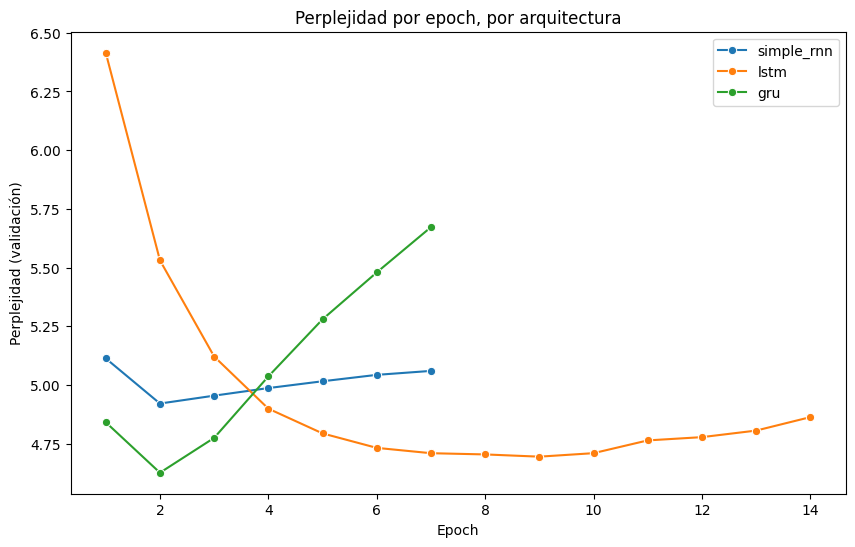

simple_rnn: mejor perplejidad = 4.921 (epoch 2, entrenó 7 epochs)
lstm: mejor perplejidad = 4.694 (epoch 9, entrenó 14 epochs)
gru: mejor perplejidad = 4.626 (epoch 2, entrenó 7 epochs)


In [17]:
import pickle

with open('histories.pkl', 'wb') as f:
    pickle.dump(histories, f)

plt.figure(figsize=(10, 6))
for arch_name, history_ppl in histories.items():
    epoch_count = range(1, len(history_ppl) + 1)
    sns.lineplot(x=epoch_count, y=history_ppl, label=arch_name, marker='o')

plt.xlabel('Epoch')
plt.ylabel('Perplejidad (validación)')
plt.title('Perplejidad por epoch, por arquitectura')
plt.legend()
plt.show()

for arch_name, history_ppl in histories.items():
    print(f"{arch_name}: mejor perplejidad = {min(history_ppl):.3f} (epoch {np.argmin(history_ppl) + 1}, entrenó {len(history_ppl)} epochs)")

# Generación de secuencias

### 12 - Cargar los modelos entrenados

Para generar texto necesito los checkpoints (`.keras`) que guardó el callback durante el entrenamiento en Colab. Los cargo acá; si no están presentes en esta carpeta (por ejemplo, si todavía no los bajé de Colab), lo aviso explícitamente en vez de fallar con un error críptico más abajo.

In [18]:
trained_models = {}
for arch_name in ['simple_rnn', 'lstm', 'gru']:
    path = f'model_{arch_name}.keras'
    if os.path.exists(path):
        trained_models[arch_name] = keras.models.load_model(path)
        print(f"Cargado {path}")
    else:
        print(f"[AVISO] No encontré {path} en esta carpeta. "
              f"Bajalo de Colab (donde lo guardó el callback durante el entrenamiento) "
              f"y ponelo junto a este notebook para poder generar texto con esa arquitectura.")

trained_models

Cargado model_simple_rnn.keras
Cargado model_lstm.keras
Cargado model_gru.keras


{'simple_rnn': <Sequential name=simple_rnn, built=True>,
 'lstm': <Sequential name=lstm, built=True>,
 'gru': <Sequential name=gru, built=True>}

### 13 - Encoding/decoding y greedy search

`encode`/`decode` son las funciones inversas de `char2idx`/`idx2char` pero operando sobre texto (en vez de tokens ya separados): `encode` tokeniza un string y lo paddea con `pre`-padding a `max_context_size` (así, si el texto semilla es más corto que 100 caracteres, el modelo igual recibe una entrada de la forma que vio en entrenamiento). Agrego `.lower()` dentro de `encode` (el notebook de ejemplo no lo hacía en esta función puntual, aunque sí en otras) para que no explote con un `KeyError` si el texto semilla tiene mayúsculas, ya que todo nuestro vocabulario es minúscula.

**Greedy search** (`generate_seq`): en cada paso, tomo la distribución de probabilidad que da el modelo para el siguiente carácter (`model.predict(...)[0, -1, :]`, la salida del último timestep) y me quedo con el `argmax`. Repito, agregando el carácter elegido al texto y volviendo a encodear todo (el padding trunca automáticamente por la izquierda una vez que el texto supera los 100 caracteres, así que efectivamente uso siempre los últimos 100 caracteres como contexto).

**Caveat a tener en cuenta al interpretar resultados:** el token de padding es `0`, que en nuestro vocabulario (ordenado alfabéticamente) es justo el espacio `' '`. Esto significa que con una semilla corta (por ejemplo "habia una vez", 13 caracteres), el modelo en realidad recibe "muchísimos espacios seguidos + el texto semilla" (87 espacios + 13 caracteres = 100), una entrada bastante distinta a lo que vio en entrenamiento (donde nunca hay más de un espacio seguido, por la limpieza que hicimos). Puede afectar la calidad de los primeros caracteres generados con semillas cortas; con semillas más largas (cercanas a 100 caracteres) este efecto desaparece.

In [19]:
def encode(text, max_length=max_context_size):
    encoded = [char2idx[ch] for ch in text.lower()]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')
    return encoded


def decode(seq):
    return ''.join(idx2char[i] for i in seq)


def generate_seq(model, seed_text, n_chars, max_length=max_context_size):
    """Greedy search: en cada paso agrega el carácter de mayor probabilidad."""
    output_text = seed_text
    for _ in range(n_chars):
        encoded = encode(output_text, max_length)
        y_hat = np.argmax(model.predict(encoded, verbose=0)[0, -1, :])
        output_text += idx2char[y_hat]
    return output_text

### 14 - Beam search (determinístico y estocástico)

Adapto la implementación de la cátedra. La idea general (ya la expliqué en el chat): mantener `num_beams` caminos en paralelo, y en cada paso expandir los `num_beams` caminos actuales con los `vocab_size` caracteres posibles, quedándome con los `num_beams` mejores de esos `num_beams × vocab_size` candidatos.

`select_candidates` hace ese filtrado en cada paso:
- Aplana todos los candidatos (`num_beams × vocab_size`) en un solo array de log-probabilidades acumuladas (`log P(candidato) = log P(nuevo carácter) + log-prob acumulada del camino del que viene`).
- **Modo `'det'`** (determinístico): ordena y toma los `num_beams` de mayor probabilidad acumulada (`argsort`).
- **Modo `'sto'`** (estocástico): samplea `num_beams` candidatos de una softmax sobre esas log-probabilidades divididas por la temperatura (`np.random.choice(..., p=softmax(pred_large/temp))`).
- Como los candidatos están "aplanados", `idx_select // vocab_size` recupera de qué camino (beam) viene cada candidato elegido, y `idx_select % vocab_size` qué carácter nuevo le corresponde. Con eso reconstruye los `num_beams` caminos actualizados.

Repasé esta parte del código de la cátedra con cuidado (después de los bugs que encontré en las secciones anteriores) y, a diferencia del callback, **no encontré errores acá**: el manejo de la ventana deslizante de contexto (`hist[i+1:]`) y la reconstrucción de índices están bien.

In [20]:
def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    # colecto todas las probabilidades (aplanadas) para la siguiente búsqueda
    pred_large = []
    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1e-10) + history_probs[idx])
    pred_large = np.array(pred_large)

    # criterio de selección
    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]  # beam search determinista
    elif mode == 'sto':
        idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large / temp))  # con muestreo aleatorio
    else:
        raise ValueError(f'Modo de selección inválido. Se recibió {mode!r}; se admiten "det" y "sto".')

    # traducir a índices de token en el vocabulario
    new_history_tokens = np.concatenate((
        np.array(history_tokens)[idx_select // vocab_size],
        np.array([idx_select % vocab_size]).T,
    ), axis=1)

    # devolver el producto (en log) de las probabilidades y la secuencia de tokens seleccionados
    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, n_chars, input, temp=1, mode='det'):
    # primera iteración
    encoded = encode(input)
    y_hat = model.predict(encoded, verbose=0)[0, -1, :]
    vocab_size = y_hat.shape[0]

    history_probs = [0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates([y_hat], num_beams, vocab_size, history_probs, history_tokens, temp, mode)

    # loop de beam search
    for i in range(n_chars - 1):
        preds = []
        for hist in history_tokens:
            input_update = np.array([hist[i + 1:]]).copy()
            y_hat = model.predict(input_update, verbose=0)[0, -1, :]
            preds.append(y_hat)

        history_probs, history_tokens = select_candidates(preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode)

    return history_tokens[:, -(len(input) + n_chars):]

### 15 - Greedy search sobre las tres arquitecturas

Genero 200 caracteres a partir de la misma semilla con cada arquitectura entrenada, para comparar cómo escribe cada una en su modo más simple (y más propenso a repetirse).

In [21]:
SEED_TEXT = 'sherlock holmes miró atentamente el sobre y dijo'

if not trained_models:
    print("No hay modelos cargados todavía (ver sección 12). Nada para generar por ahora.")
else:
    for arch_name, model in trained_models.items():
        print(f"\n--- {arch_name} (greedy) ---")
        print(generate_seq(model, SEED_TEXT, n_chars=200))


--- simple_rnn (greedy) ---
sherlock holmes miró atentamente el sobre y dijo holmes se encontraba en la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de

--- lstm (greedy) ---
sherlock holmes miró atentamente el sobre y dijo holmes se encontraba en la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de la cara de

--- gru (greedy) ---
sherlock holmes miró atentamente el sobre y dijo holmes se le ha poder recorrido de la cama de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de


**Interpretación (greedy search)**

Las tres arquitecturas quedan atrapadas en un **bucle de repetición**: `simple_rnn` y `lstm` generan exactamente el mismo texto (`"...en la cara de la cara de la cara de..."`) y `gru` cae en `"...de la casa de la casa de la casa..."`. Sobre las ~52 palabras generadas, la proporción de palabras distintas es apenas 0.13 (`simple_rnn`, `lstm`) y 0.19 (`gru`).

El motivo es que greedy es determinístico y el bucle se **auto-refuerza**: una vez que "de la casa de la" entra en la ventana de contexto de 100 caracteres, el modelo le asigna alta probabilidad a repetir ese patrón, el `argmax` lo elige, y eso vuelve a reforzar el patrón. No hay ningún mecanismo que lo saque de ahí. Al principio los tres producen español bien formado (ortografía, concordancia y puntuación correctas), es decir que el modelo aprendió estructura local, pero no tiene una noción de "ya dije esto". Esto es consistente con las perplejidades obtenidas (~4.7): predice bien carácter a carácter, pero eso no alcanza para sostener coherencia a largo plazo.

Que `simple_rnn` y `lstm` coincidan carácter por carácter no es un error (son modelos distintos, con pesos de tamaños distintos): ambos convergen al mismo camino de máxima probabilidad local para esta semilla.

### 16 - Beam search determinístico

Uso el modelo con mejor perplejidad (GRU) y comparo unos pocos beams (`num_beams=5`) contra el greedy search anterior, con la misma semilla.

In [22]:
if 'gru' not in trained_models:
    print("Necesito model_gru.keras cargado (ver sección 12) para esta demo.")
else:
    best_model = trained_models['gru']
    resultados = beam_search(best_model, num_beams=5, n_chars=200, input=SEED_TEXT, mode='det')
    for i, seq in enumerate(resultados):
        print(f"beam {i}: {decode(seq)}\n")

beam 0: sherlock holmes miró atentamente el sobre y dijo holmes—. estoy seguro de que los detalles que había encontrarse de los periódicos de las cosas de la campanilla de la campanilla de la campanilla de la campanilla de la campanilla de la campanilla de

beam 1: sherlock holmes miró atentamente el sobre y dijo holmes—. estoy seguro de que los detalles que había encontrarse de los periódicos de las cosas de la campanilla de la campanilla de la campanilla de la campanilla de la campanilla de la campanilla. —

beam 2: sherlock holmes miró atentamente el sobre y dijo holmes—. estoy seguro de que los detalles que había encontrarse de los periódicos de las cosas de la campanilla de la campanilla de la campanilla de la campanilla de la campanilla de la campanilla, y

beam 3: sherlock holmes miró atentamente el sobre y dijo holmes—. estoy seguro de que los detalles que había encontrarse de los periódicos de las cosas de la campanilla de la campanilla de la campanilla de la campanilla de la 

**Interpretación (beam search determinístico)**

Beam search tampoco resuelve el problema: la mejor hipótesis termina en `"...de la campanilla de la campanilla de la campanilla..."`, con una proporción de palabras distintas de ~0.40-0.43 (algo mejor que greedy, pero sigue siendo un bucle). Además se observa el otro problema típico de este método: **los 5 beams son prácticamente idénticos** entre sí y solo difieren en los últimos 1-2 caracteres (`. —`, `, y`, ` y `, `. e`). Como el criterio es maximizar la probabilidad acumulada, todos los caminos que sobreviven comparten el mismo prefijo de alta probabilidad, así que el "ancho" del haz no aporta diversidad real. Además, maximizar la probabilidad conjunta favorece justamente las frases más predecibles, y una frase repetida es muy predecible.

Un detalle a favor: empezó con una frase más elaborada que greedy (`"estoy seguro de que los detalles que había encontrarse de los periódicos..."`), es decir que explorar más caminos ayudó a salir un poco más tarde del bucle, pero no a evitarlo.

### 17 - Beam search estocástico: efecto de la temperatura

Genero con el mismo modelo y semilla, variando `temp` entre valores bajos (más conservador/determinístico) y altos (más diverso/arriesgado), para observar el efecto descripto en el chat.

In [23]:
if 'gru' not in trained_models:
    print("Necesito model_gru.keras cargado (ver sección 12) para esta demo.")
else:
    best_model = trained_models['gru']
    for temp in [0.2, 0.7, 1.0, 1.5]:
        print(f"\n=== temperatura = {temp} ===")
        resultado = beam_search(best_model, num_beams=3, n_chars=200, input=SEED_TEXT, temp=temp, mode='sto')
        print(decode(resultado[0]))


=== temperatura = 0.2 ===
sherlock holmes miró atentamente el sobre y dijo que la señorita tan sólo de la casa de la campanilla de la casa de la casa de la casa de la casa de la casa de la casa, y el señor holmes, con una de las casas de la campanilla de la casa de la campa

=== temperatura = 0.7 ===
sherlock holmes miró atentamente el sobre y dijo que no se le sucedió la conducido en la ventana, y me dijo holmes—. estaba con un asunto se levantó que se levantó de uno de los periódicos de la cabeza de la muchacha en la investigación de la luz d

=== temperatura = 1.0 ===
sherlock holmes miró atentamente el sobre y dijo que había encontrado la señorita stoner de su casa, y que me parece que se encontraba en la ventana, y los después de las manos. —de escribir en la cabeza de las dos hombres. —¿y qué desea nada de un

=== temperatura = 1.5 ===
sherlock holmes miró atentamente el sobre y dijo con su casa con la madración. sherlock holmes se había alterior es la caja, de la ventana alguna

**Interpretación (beam search estocástico y temperatura)**

Acá sí aparece una diferencia clara, aunque con un matiz importante: **no es el modo estocástico por sí solo lo que resuelve el bucle, sino usar una temperatura adecuada**.

| Temperatura | Palabras distintas / total | Palabras que no existen en el corpus | Observación |
|---|---|---|---|
| 0.2 | 0.36 | 0* | Vuelve a caer en el bucle (`"de la casa de la casa de la casa..."`): con una temperatura tan baja la distribución queda casi degenerada en el máximo y el muestreo se comporta como el modo determinístico. |
| **0.7** | **0.66** | 0 | Texto variado, con diálogo (`—`), sin bucles. Es un buen equilibrio. |
| **1.0** | **0.70** | 0 | El más natural en apariencia: incluye signos de apertura (`¿`), cambia de tema entre oraciones, sin bucles ni palabras inventadas. |
| 1.5 | 0.73 | 4 (`madración`, `alterior`, `llevia`, `bleb`) | La diversidad sigue subiendo pero aparecen **palabras inventadas**: la distribución se aplana tanto que se muestrean caracteres poco probables y se rompe la ortografía. |

\* La única "palabra" no presente en el corpus para `temp=0.2` es `campa`, que es solo `campanilla` cortada por el límite de 200 caracteres.

Esto muestra el trade-off exploración vs. explotación de la temperatura: valores bajos repiten (explotan lo que el modelo ya sabe), valores altos se vuelven incoherentes (exploran de más), y la zona útil para este modelo está aproximadamente entre **0.7 y 1.0**.

**Salvedad:** los números y textos de esta sección salen de **una sola muestra por temperatura** (y solo se mostró el primer beam), con una única semilla de texto. Como el muestreo es aleatorio, otra corrida daría textos distintos; la tendencia (bucle con temperatura baja, palabras inventadas con temperatura alta) es la esperable, pero para afirmarlo con más seguridad habría que promediar sobre varias corridas y varias semillas.

## Conclusiones

- **Perplejidad:** las tres arquitecturas llegan a perplejidades similares en validación (GRU 4.650 < LSTM 4.746 < SimpleRNN 4.852, sobre una cota de 67 para un modelo que adivina al azar) y las tres sobreajustan rápido (la mejor época es la 2, 8 y 3 respectivamente), por lo que el early stopping por perplejidad fue clave. GRU fue la más rápida y la mejor.
- **La perplejidad no garantiza buena generación:** una diferencia de 0.1-0.2 en perplejidad no se traduce en diferencias visibles en el texto generado; lo que más pesa es la **estrategia de decodificación**. Con greedy, las tres arquitecturas caen en el mismo tipo de bucle.
- **Estrategias de generación:** greedy y beam search determinístico producen bucles de repetición (beam search un poco menos, pero con beams casi idénticos entre sí). El beam search estocástico con temperatura entre 0.7 y 1.0 fue el único que produjo texto variado y sin bucles; con temperatura baja (0.2) repite igual que los métodos determinísticos, y con temperatura alta (1.5) aparecen palabras inventadas.
- **Limitaciones:** el texto generado es gramaticalmente plausible a nivel local (ortografía, puntuación, diálogo) pero **sin coherencia semántica** entre oraciones, lo esperable de un modelo por caracteres de 200 unidades entrenado sobre ~600 mil caracteres. Además, la comparación de estrategias se hizo sobre una sola semilla y una sola muestra por configuración (y solo con GRU para beam search), y con semillas cortas el padding con espacios podría afectar los primeros caracteres generados.